In [ ]:
from utils.funciones_minio import crear_cliente_minio, bajar_minio
from utils.config import PATH_DATASETS_MODELOS
from funciones_texto import bajar_df_texto

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


In [3]:
df = bajar_minio(client=cliente, path=PATH_DATASETS_MODELOS, minio_object=objeto)

In [4]:
print(df.shape)
df.head()

(23727, 5)


,id,Descripcion,Anuncia,venta,alquiler
0,110289316,Descubre la elegancia y el lujo en este espect...,Intermediario,1,0
1,110239661,"ÁTICO REFORMADO EXTERIOR CON TRES TERRAZAS, GA...",Intermediario,1,0
2,110138264,JOYA ÚNICA EN LEGAZPI · ÁTICO DÚPLEX CON SOLÁR...,Intermediario,1,0
3,109895689,Moderna vivienda en Legazpi ubicada en el skyl...,Intermediario,1,0
4,109688685,"Vivir el centro de Madrid así, es un privilegi...",Intermediario,1,0


In [5]:
X = df["Descripcion"].astype(str)
y = df["Anuncia"].astype(str)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
nltk.download('stopwords')
spanish_stopwords = stopwords.words('spanish')

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1,2),
        stop_words=spanish_stopwords
    )),
    ("clf", MultinomialNB())
])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sergi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
history = model.fit(X_train, y_train)

In [9]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

Intermediario       0.91      0.93      0.92      3862
   Particular       0.68      0.60      0.64       759
    Promotora       0.59      0.70      0.64       125

     accuracy                           0.87      4746
    macro avg       0.73      0.74      0.73      4746
 weighted avg       0.87      0.87      0.87      4746



## Matriz de confusión
Visualiza los aciertos y errores del modelo.

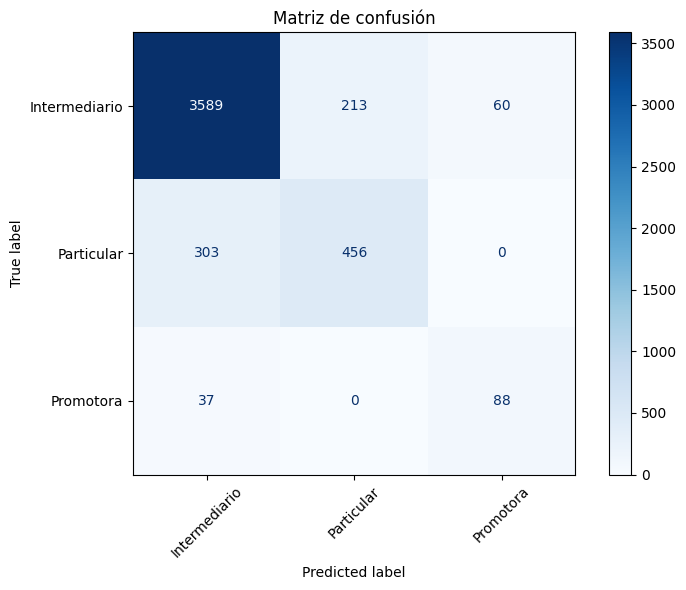

In [12]:
labels = sorted(y_test.unique())

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=labels,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

## Matriz de confusión normalizada
Muestra proporciones en lugar de valores absolutos.

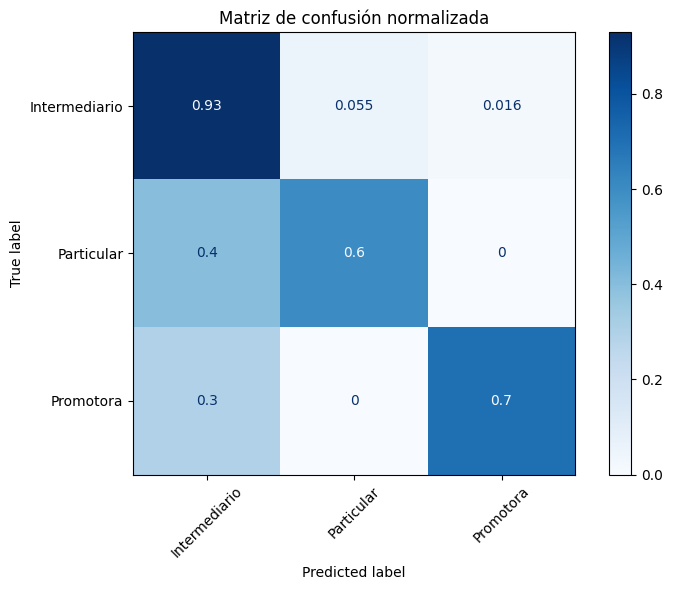

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=labels,
    cmap="Blues",
    normalize="true",
    xticks_rotation=45,
    ax=ax
)
plt.title("Matriz de confusión normalizada")
plt.tight_layout()
plt.show()

## Términos más importantes por clase
Palabras más representativas de cada categoría.

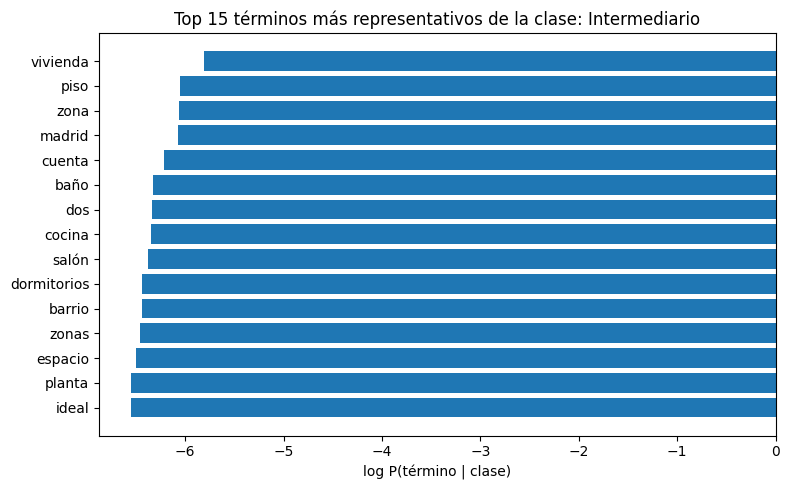

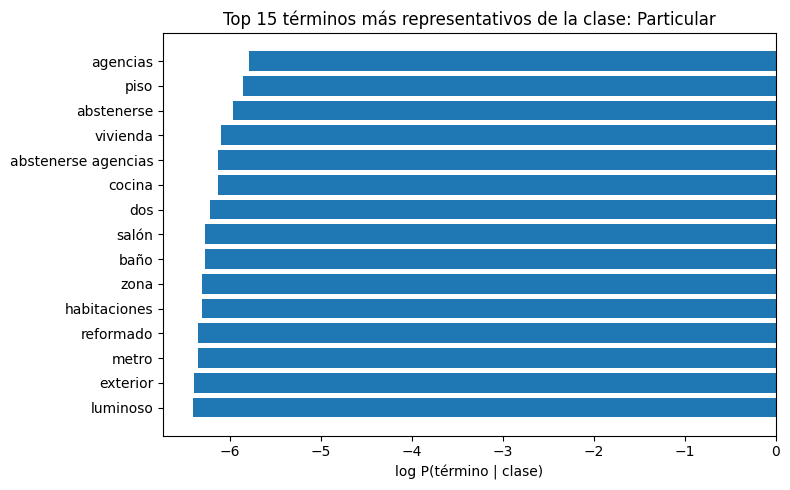

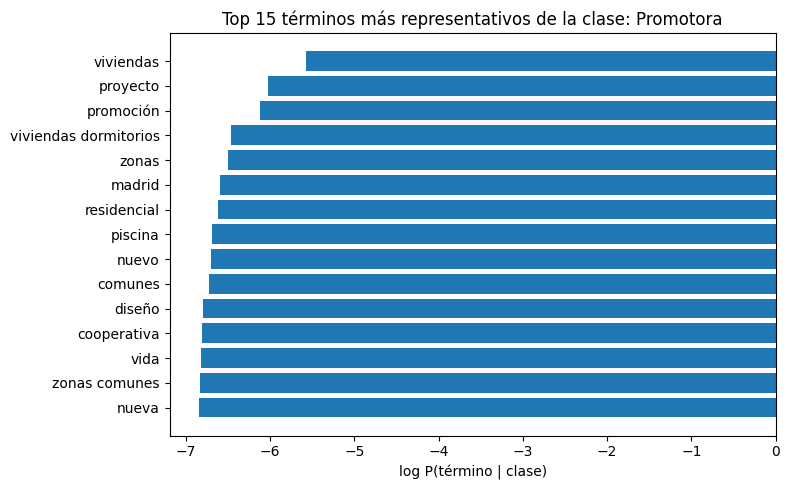

In [14]:
tfidf = model.named_steps["tfidf"]
nb = model.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())
classes = nb.classes_

top_n = 15

for i, clase in enumerate(classes):
    top_idx = np.argsort(nb.feature_log_prob_[i])[-top_n:][::-1]
    
    plt.figure(figsize=(8, 5))
    plt.barh(feature_names[top_idx][::-1], nb.feature_log_prob_[i][top_idx][::-1])
    plt.title(f"Top {top_n} términos más representativos de la clase: {clase}")
    plt.xlabel("log P(término | clase)")
    plt.tight_layout()
    plt.show()

## Resumen de términos por clase
Tabla con las palabras más relevantes.

In [15]:
top_n = 20
resumen_features = {}

for i, clase in enumerate(classes):
    top_idx = np.argsort(nb.feature_log_prob_[i])[-top_n:][::-1]
    resumen_features[clase] = feature_names[top_idx]

top_features_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in resumen_features.items()]))
top_features_df

,Intermediario,Particular,Promotora
0,vivienda,agencias,viviendas
1,piso,piso,proyecto
2,zona,abstenerse,promoción
3,madrid,vivienda,viviendas dormitorios
4,cuenta,abstenerse agencias,zonas
5,baño,cocina,madrid
6,dos,dos,residencial
7,cocina,salón,piscina
8,salón,baño,nuevo
9,dormitorios,zona,comunes


## Errores del modelo
Ejemplos donde el modelo se equivoca.

In [18]:
errores = pd.DataFrame({
    "texto": X_test.values,
    "real": y_test.values,
    "pred": y_pred
})

errores = errores[errores["real"] != errores["pred"]].copy()
errores["texto"] = errores["texto"].str[:300]

print(f"Número de errores: {len(errores)}")
errores.head(20)

Número de errores: 613


,texto,real,pred
2,VIVIENDA TEMPORAL PISO EN ALQUILER PARA ESTAN...,Intermediario,Particular
11,APARTAMENTO NUEVO A ESTRENAR · DISEÑO APARTAHO...,Particular,Intermediario
18,"Piso en la calle Tortosa, de 2 habitaciones en...",Particular,Intermediario
46,"Maravillosa vivienda en zona tranquila, ubicad...",Particular,Intermediario
47,Propietario vende magnífico dúplex ubicado en ...,Particular,Intermediario
53,Magnifico Atico con terraza de 20 m2 Consta de...,Intermediario,Particular
57,NO COBRAMOS COMISION DE AGENCIA¡excelente dupl...,Intermediario,Particular
67,Piso y concesión de plaza de garaje en venta e...,Particular,Intermediario
72,Piso semi reformado de 2 habitaciones con terr...,Intermediario,Particular
76,Inversiones La Moraleja presenta en exclusiva ...,Intermediario,Particular


## Confianza de las predicciones
Distribución de probabilidades máximas.

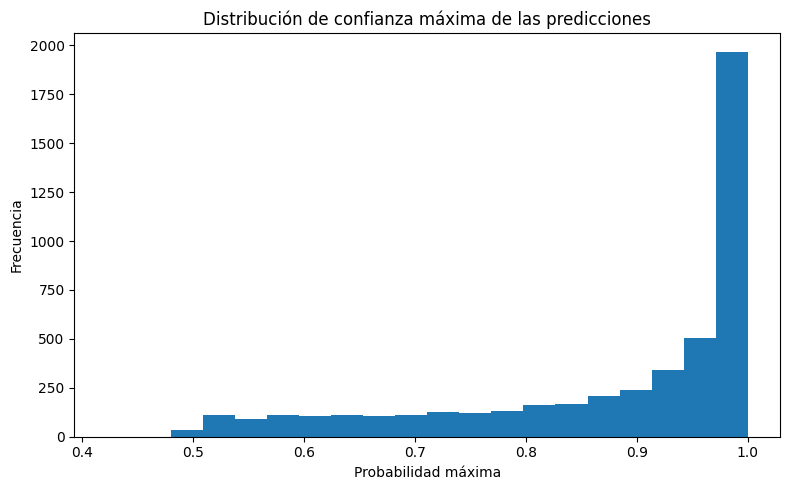

In [19]:
y_proba = model.predict_proba(X_test)
confianza_max = y_proba.max(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(confianza_max, bins=20)
plt.title("Distribución de confianza máxima de las predicciones")
plt.xlabel("Probabilidad máxima")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Casos más inciertos
Ejemplos con menor confianza.

In [20]:
inciertos = pd.DataFrame({
    "texto": X_test.values,
    "real": y_test.values,
    "pred": y_pred,
    "confianza": confianza_max
}).sort_values("confianza", ascending=True)

inciertos["texto"] = inciertos["texto"].str[:300]
inciertos.head(20)

,texto,real,pred,confianza
647,VENTA DIRECTA PROMOTORA fundada en 1973. OBRAS...,Promotora,Intermediario,0.422138
560,DISPONIBLE EN: Mayo. Reserve en línea haciend...,Intermediario,Promotora,0.482877
3290,"Piscina, piscina climatizada, portero 24h, pád...",Particular,Particular,0.483864
223,DISPONIBLE EN: Marzo. Reserve en línea hacien...,Intermediario,Intermediario,0.484079
687,NEW LUXURY FLAT at UNESCO Heritage Monument - ...,Particular,Particular,0.495695
4743,Alquilo estudio en Puerta de Hierro/ zona Arro...,Particular,Intermediario,0.499827
2270,Colomba Boutique Inmobiliaria Alquila piso de ...,Intermediario,Particular,0.500282
4051,"Luz, amplitud y garaje en finca con jardín en ...",Particular,Particular,0.500601
1694,"precioso apartamento exterior, muy bien comuni...",Intermediario,Intermediario,0.500788
4543,Precioso piso en zona Palacio! Consta de 1 h...,Intermediario,Intermediario,0.501277
